First, we'll install the Kaggle API client, create the necessary directory for the `kaggle.json` file, and set the correct permissions.

In [1]:
# Create .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

In [2]:
# Move kaggle.json to the .kaggle directory
!mv /content/kaggle.json ~/.kaggle/

mv: cannot stat '/content/kaggle.json': No such file or directory


In [3]:
# Set appropriate permissions for kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


Now that the Kaggle API is set up, you can use `!kaggle` commands to download datasets. Please replace `<dataset-owner>/<dataset-name>` with the actual dataset you wish to download.

In [4]:
# Example: Download a Kaggle dataset
# !kaggle datasets download -d <dataset-owner>/<dataset-name>
# Example: !kaggle datasets download -d usdot/flight-delays

# Or to download a specific competition data
# !kaggle competitions download -c <competition-name>

# print("Kaggle API setup complete. Please add your download command here.")
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:52<00:00, 21.6MB/s]



In [5]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogsvscats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [19]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Dropout

In [7]:
# Generators
train_ds= keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

val_ds= keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


 This Generator make the image into numpy format where the pixel value range from 0 to 256, we have to normalize them so that the value should be in range of 0 to 1

In [8]:
def process(image, label):
  image=tf.cast(image/255. , tf.float32)
  return image, label

train_ds=train_ds.map(process)
val_ds=val_ds.map(process)

In [9]:
model=Sequential()
# Convolution Layer
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

# Flatten Layer
model.add(Flatten())

# Fully Conected Layer
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,714,241 (14.17 MB)

 Trainable params: 3,714,241 (14.17 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'] )

In [14]:
history=model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 65ms/step - accuracy: 0.6217 - loss: 0.6474 - val_accuracy: 0.7096 - val_loss: 0.5690
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.7337 - loss: 0.5336 - val_accuracy: 0.7468 - val_loss: 0.5117
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.8142 - loss: 0.4000 - val_accuracy: 0.7656 - val_loss: 0.5487
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 59ms/step - accuracy: 0.8973 - loss: 0.2428 - val_accuracy: 0.7452 - val_loss: 0.8498
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 58ms/step - accuracy: 0.9527 - loss: 0.1257 - val_accuracy: 0.7566 - val_loss: 1.1232
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.9744 - loss: 0.0748 - val_accuracy: 0.7544 - val_loss: 1.2545
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 67ms/step - accuracy: 0.9836 - loss: 0.0518 - val_accuracy: 0.7510 - val_loss: 1.5021
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.9882 - loss: 0.0385 - 

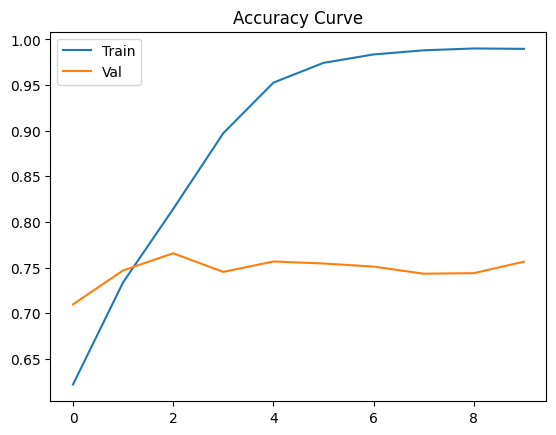

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy Curve")
plt.legend()
plt.show()

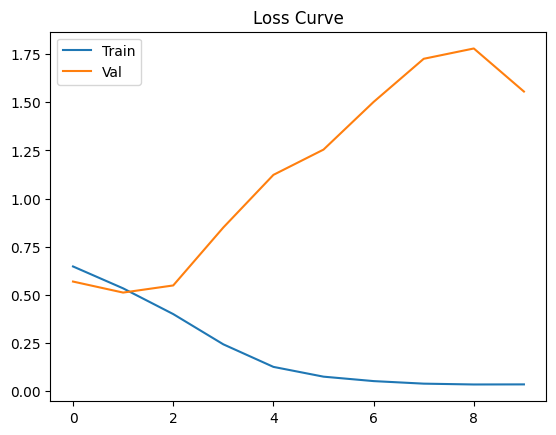

In [18]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss Curve")
plt.legend()
plt.show()

# Lets try to improve Model Improvement

In [20]:
model=Sequential()
# Convolution Layer
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

# Flatten Layer
model.add(Flatten())

# Fully Conected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,714,625 (14.17 MB)

 Trainable params: 3,714,433 (14.17 MB)

 Non-trainable params: 192 (768.00 B)

In [22]:
model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'] )

In [23]:
history=model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 70ms/step - accuracy: 0.6316 - loss: 0.7684 - val_accuracy: 0.6526 - val_loss: 0.6045
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 74ms/step - accuracy: 0.7430 - loss: 0.5185 - val_accuracy: 0.7522 - val_loss: 0.5362
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.7871 - loss: 0.4437 - val_accuracy: 0.7630 - val_loss: 0.4903
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.8242 - loss: 0.3856 - val_accuracy: 0.7542 - val_loss: 0.5129
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.8556 - loss: 0.3207 - val_accuracy: 0.7744 - val_loss: 0.5666
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8869 - loss: 0.2599 - val_accuracy: 0.7618 - val_loss: 0.5626
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.9146 - loss: 0.1977 - val_accuracy: 0.7990 - val_loss: 0.5986
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.9380 - loss: 0.1457 - 

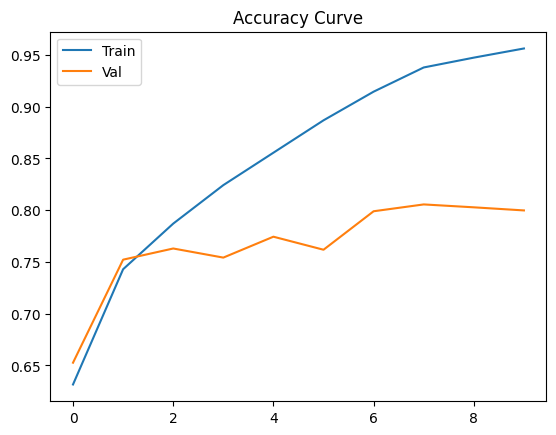

In [24]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy Curve")
plt.legend()
plt.show()

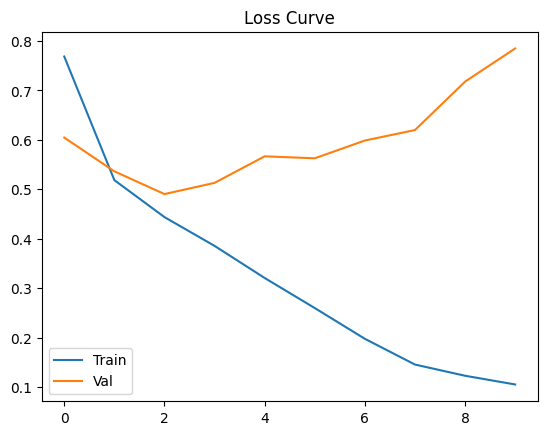

In [25]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss Curve")
plt.legend()
plt.show()

# Prediction on unseen data

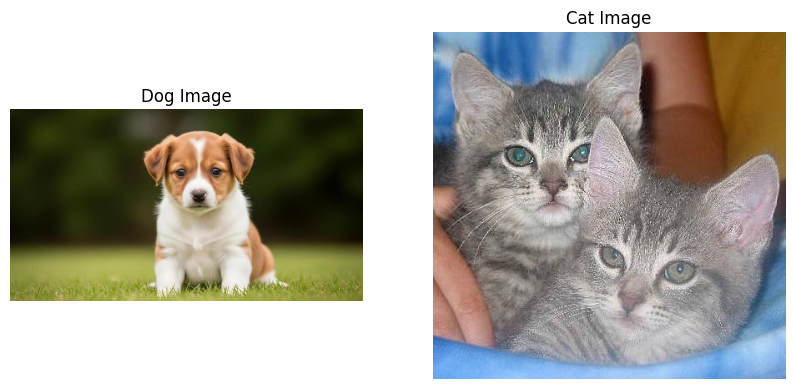

In [58]:
import cv2
import matplotlib.pyplot as plt

test_img_dog=cv2.imread('/content/dog.png')
test_img_cat=cv2.imread('/content/test/cats/cat.10021.jpg')

# Convert BGR to RGB for matplotlib display
test_img_dog_rgb = cv2.cvtColor(test_img_dog, cv2.COLOR_BGR2RGB)
test_img_cat_rgb = cv2.cvtColor(test_img_cat, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(test_img_dog_rgb)
plt.title("Dog Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(test_img_cat_rgb)
plt.title("Cat Image")
plt.axis('off')

plt.show()

In [59]:
test_img_dog=cv2.resize(test_img_dog_rgb, (256, 256))
test_img_cat=cv2.resize(test_img_cat_rgb, (256, 256))

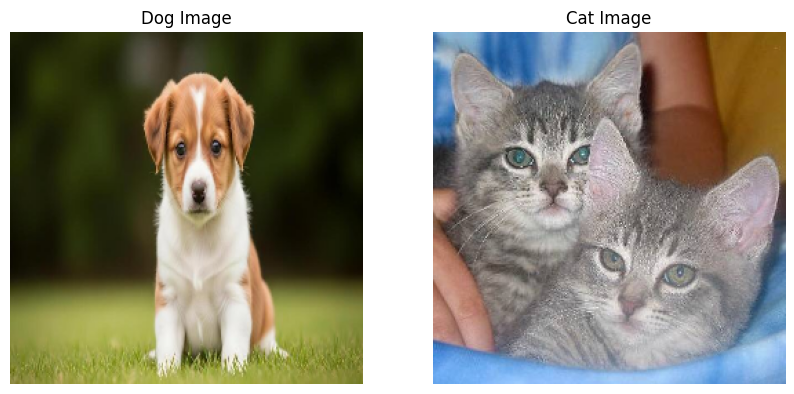

In [60]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(test_img_dog)
plt.title("Dog Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(test_img_cat)
plt.title("Cat Image")
plt.axis('off')

plt.show()

In [61]:
test_input_dog= test_img_dog.reshape(1, 256, 256, 3)
test_input_cat= test_img_cat.reshape(1, 256, 256, 3)

In [62]:
test_input_dog_normalized = test_input_dog / 255.
test_input_cat_normalized = test_input_cat / 255.

print("Prediction for Dog image (normalized):")
print(model.predict(test_input_dog_normalized))

print("\nPrediction for Cat image (normalized):")
print(model.predict(test_input_cat_normalized))

Prediction for Dog image (normalized):
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[0.99840623]]

Prediction for Cat image (normalized):
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.00074274]]


# Now the Thing is Model is overfitting towards Dog as here we need to do Data Augmentation to overcome this. But prediction on training data is good and accurate.